# Script of postprocessing plots for validation tables

Example of script if you want to play with your validation tables and see what 
the validation looks like, per regions (bias, RMSD, correlation, Taylor diagrams,...).  
This script will be mainly used by WP4.  

- Input file format: VALID_{var}_ {year}_{model}.parquet  

_Authors: Capet A._

In [1]:
import xarray as xr
import matplotlib.pyplot as plt 

from  matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter 

import numpy as np
import pandas as pd

from cmocean import cm
from matplotlib.colors import ListedColormap

from cartopy import crs as ccrs
import cartopy.feature as cf

import datetime

In [8]:
# Path of your validation table directory
datadir = '/hpcperm/bel9956/codeblue/validation/'

## Load regions

25


/usr/local/apps/python3/3.13.13-01/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


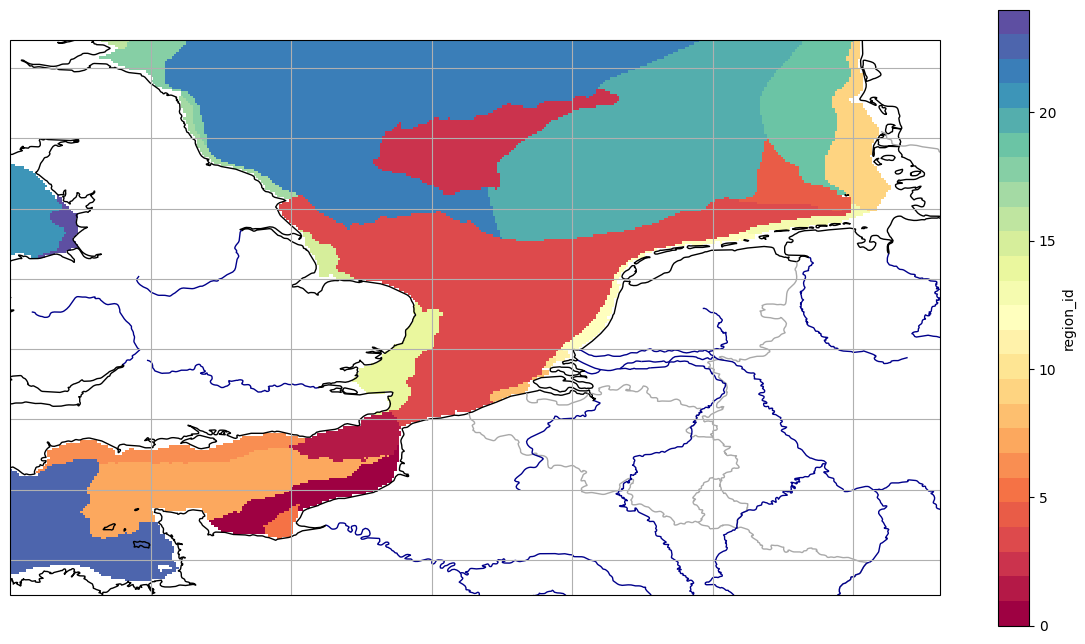

In [6]:
if True: 
    regionfile = '/home/cvao/postprocessing-toolbox/NetCDF_manipulation/Geospatial/Bathymetry_NoS_with_regions_AC.nc'
    xreg = xr.load_dataset(regionfile)
    nreg = (xreg.region_id.max().values+1).astype(int)
    print(nreg)
    
    regcmap = ListedColormap(plt.cm.Spectral(np.linspace(0, 1, nreg)))
    
    fig = plt.figure(figsize = (15,8))
    ax= fig.add_subplot(111, projection =ccrs.PlateCarree())
    xreg.region_id.plot(cmap=regcmap)
    
    ax.gridlines()
    ax.coastlines(color='k')
    # Countries' borders
    ax.add_feature(cf.BORDERS, color = 'darkgrey')
    ax.add_feature(cf.RIVERS, color = 'darkblue')

In [10]:
var = 'chl'
year = 2010
model = 'coherens'

dflt = pd.read_parquet(datadir+'VALID_%s_%s_%s.parquet'%(var,year,model))

if True : # Actualize regions ID
    # Get coordinaates
    lons  = xr.DataArray(dflt['lon'], dims="points")
    lats  = xr.DataArray(dflt['lat'], dims="points")
    times = xr.DataArray(dflt['datetime'], dims="points")
    depths = xr.DataArray(dflt['depth'], dims="points")

    # Get Region ID
    regs = xreg['region_id'].interp({'lon':lons, 'lat':lats})
    dflt['reg']=np.round(regs)

In [11]:
dflt = dflt.dropna()

In [12]:
dflt.groupby('reg').count()['lon']

reg
0.0      22
1.0      32
2.0      30
3.0     111
4.0      67
5.0       5
6.0       4
7.0      24
8.0      14
9.0     110
10.0      1
12.0     26
13.0     21
14.0     61
15.0      6
16.0      2
17.0      2
18.0     22
19.0      4
20.0     90
22.0     41
23.0      2
Name: lon, dtype: int64

Text(0, 0.5, 'Data counts')

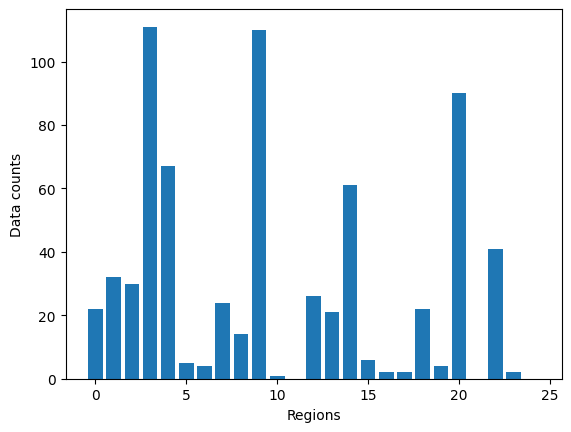

In [13]:
regdatacount = np.zeros(nreg)

for r in range(nreg):
    regdatacount[r] = dflt[dflt['reg'] == r].count()['lon']

plt.bar(np.arange(nreg), regdatacount)
plt.xlabel('Regions')
plt.ylabel('Data counts')


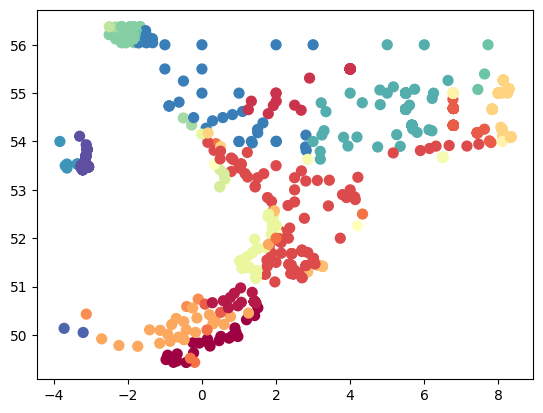

In [14]:
plt.scatter(regs['lon'],regs['lat'],50, regs, cmap=regcmap)

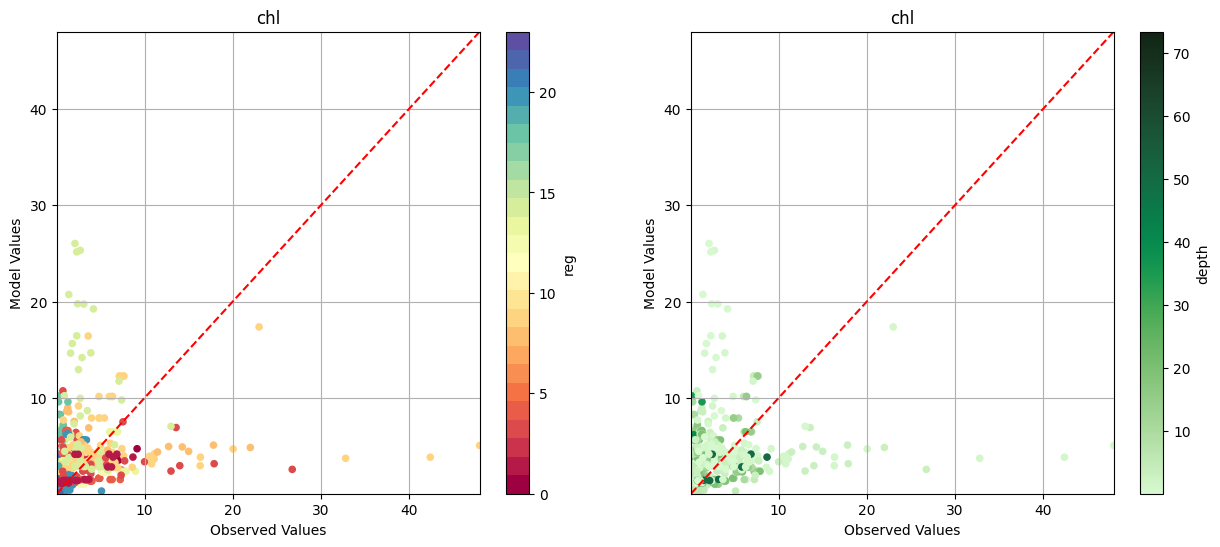

In [15]:
fig = plt.figure(figsize = (15,6))

# Left panel wtih regions 
ax= fig.add_subplot(1,2,1)

dflt.plot.scatter(x=var,y='mod', c = 'reg', ax=ax, cmap=regcmap)
ax.grid()

xmin, xmax = min(dflt[var].min(), dflt['mod'].min()), max(dflt[var].max(), dflt['mod'].max()) 
ax.set_xlim((xmin,xmax))
ax.set_ylim((xmin,xmax))
ax.set_ylabel('Model Values')
ax.set_xlabel('Observed Values')

ax.set_title(var)
ax. plot([xmin,xmax], [xmin,xmax], 'r--')

# Depth
ax= fig.add_subplot(1,2,2)

dflt.plot.scatter(x=var,y='mod', c = 'depth', ax=ax, cmap=cm.algae)
ax.grid()

xmin, xmax = min(dflt[var].min(), dflt['mod'].min()), max(dflt[var].max(), dflt['mod'].max()) 
ax.set_xlim((xmin,xmax))
ax.set_ylim((xmin,xmax))
ax.set_ylabel('Model Values')
ax.set_xlabel('Observed Values')

ax.set_title(var)
ax. plot([xmin,xmax], [xmin,xmax], 'r--')


plt.show()

## Validation Metric


For each region, based on a DOY timeseries, recomposed from MULTIYEAR regional spatial average for model and (availale) obs  : 
* BIAS
* RMSD
* CORR

-> Taylor / Target for regional CHL. 



In [16]:
stats_list = []  # Store results for each region

dflt['diff']=dflt['mod'] - dflt[var]

for reg in range(nreg):

    dfloc = dflt[dflt['reg'] == reg]

    # Compute statistics
    mod_mean = dfloc['mod'].mean()
    mod_std = dfloc['mod'].std()
    obs_mean = dfloc[var].mean()
    obs_std = dfloc[var].std()
    bias = mod_mean - obs_mean
    perc_bias = (bias / obs_mean) * 100
    corr = np.corrcoef(dfloc['mod'], dfloc[var], rowvar=False)[0, 1]
    nse = (1 - (dfloc['diff'] ** 2).sum() / ((dfloc[var] - obs_mean) ** 2).sum())
    rmsd = np.sqrt((dfloc['diff'] ** 2).mean())
    crmsd = np.sqrt((((dfloc[var]-obs_mean) - (dfloc['mod']-mod_mean)) ** 2).mean())

    # Append results as a dictionary
    stats_list.append({
        "region": reg,
        "model_mean": mod_mean,
        "model_std": mod_std,
        "obs_mean": obs_mean,
        "obs_std": obs_std,
        "bias": bias,
        "perc_bias": perc_bias,
        "correlation": corr,
        "NSE": nse,
        "RMSD": rmsd,
        "cRMSD": crmsd,
        "N" : regdatacount[reg]  # Assuming reg starts from 1 and regdatacount is ordered by region ID
    })

# Convert to DataFrame
stats_df = pd.DataFrame(stats_list)

# Save results
stats_df.to_csv("validation_metrics_%s_%s.csv" % (year,var), index=False)


/usr/local/apps/python3/3.13.13-01/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/apps/python3/3.13.13-01/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/apps/python3/3.13.13-01/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/etc/ecmwf/ssd/ssd1/jupyterhub/bel9956-jupyterhub/tmpdirs/bel9956.14031151/ipykernel_2391997/3428694206.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  nse = (1 - (dfloc['diff'] ** 2).sum() / ((dfloc[var] - obs_mean) ** 2).sum())
/usr/local/apps/python3/3.13.13-01/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/loca

In [17]:
stats_df

,region,model_mean,model_std,obs_mean,obs_std,bias,perc_bias,correlation,NSE,RMSD,cRMSD,N
0,0,2.530140,1.494692,1.128182,2.302170,1.401958,124.267021,0.350304,-0.355165,2.618375,2.211425,22.0
1,1,2.015482,1.169210,2.303750,2.440703,-0.288268,-12.512987,0.729492,0.455036,1.773392,1.749806,32.0
2,2,1.923759,1.140592,1.148667,0.885390,0.775092,67.477541,0.787045,-0.424548,1.038990,0.691906,30.0
3,3,2.246210,1.609441,2.161580,3.905752,0.084630,3.915181,0.281250,0.061514,3.766635,3.765684,111.0
4,4,2.038214,1.753529,1.782537,1.716342,0.255677,14.343436,-0.118899,-1.309280,2.588670,2.576012,67.0
5,5,1.965495,1.320973,0.824000,1.174002,1.141495,138.530990,0.450171,-1.434730,1.638472,1.175407,5.0
6,6,1.932312,0.916154,0.400000,0.286705,1.532312,383.078065,0.382795,-45.850181,1.699504,0.735073,4.0
7,7,0.668900,0.213831,0.331250,0.208103,0.337650,101.932012,0.644088,-2.479166,0.379993,0.174319,24.0
8,8,5.754185,2.118829,7.971797,7.330759,-2.217612,-27.818217,-0.390615,-0.407891,8.381875,8.083194,14.0
9,9,4.562878,2.918973,5.400727,7.249899,-0.837850,-15.513643,0.187782,-0.024373,7.304288,7.256075,110.0


In [18]:
# Initialize an empty dictionary to store metric data
metric_data = {}

# Loop through each metric and store it in the dictionary
for metric in ['bias', 'perc_bias', 'correlation', 'NSE', 'RMSD','cRMSD']:
    # Create a 2D array for each region
    metric_values = np.full_like(xreg['region_id'], np.nan, dtype=np.float32)
    
    # Fill metric values for each region
    for reg in range(nreg):
        # Get the metric value for the current region
        metric_values[xreg['region_id'] == reg] = stats_df.loc[stats_df['region'] == reg, metric]#.values
    
    # Add to the dictionary with the metric name
    metric_data[metric] = (['lat', 'lon'], metric_values)

# Create the xarray Dataset
metrics_ds = xr.Dataset(
    metric_data,
    coords={'lat': xreg.lat, 'lon': xreg.lon},
    attrs={'description': 'Validation metrics for satellite and model comparisons'}
)


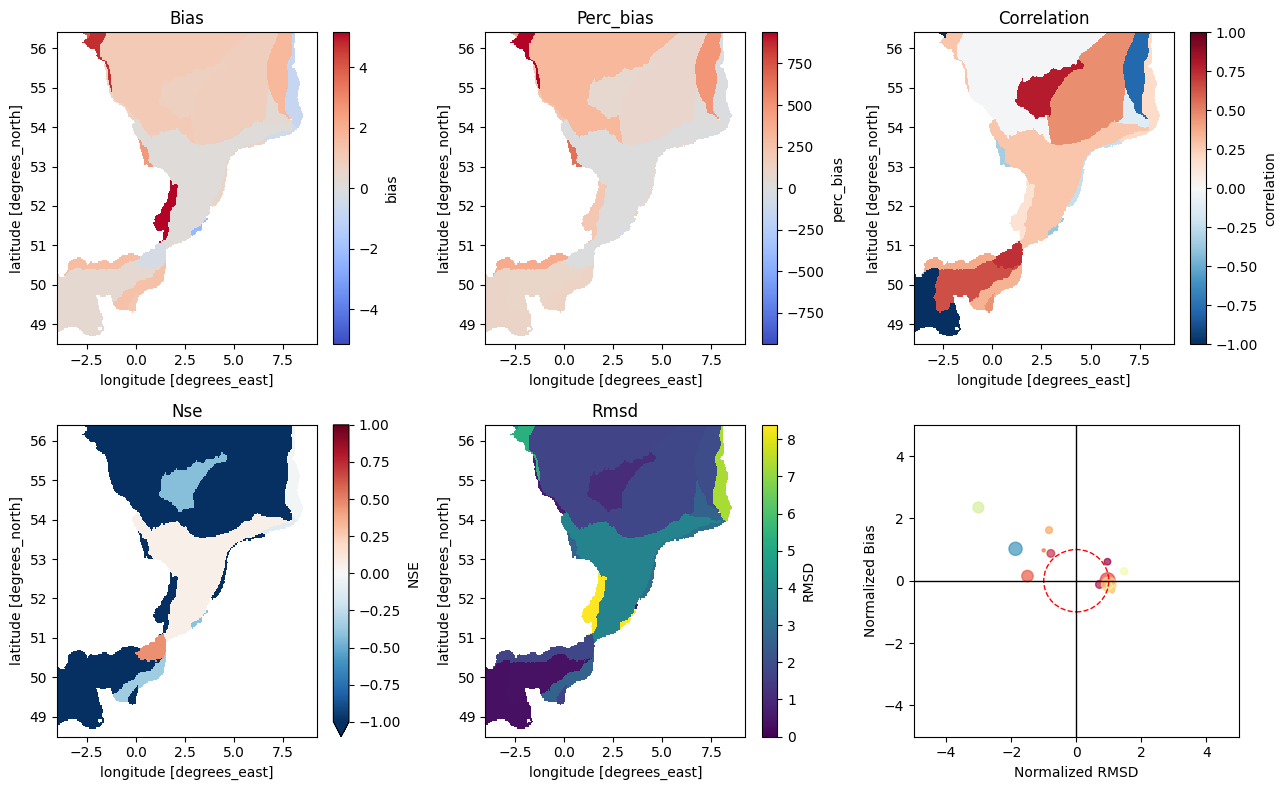

In [20]:
# metric_properties = {
#     'bias': {'cmap': 'coolwarm', 'vmin': -5, 'vmax': 5},
#     'perc_bias': {'cmap': 'coolwarm', 'vmin': -100, 'vmax': 100},
#     'correlation': {'cmap': 'RdBu_r', 'vmin': -1, 'vmax': 1},
#     'NSE': {'cmap': 'YlGnBu', 'vmin': -50, 'vmax': 1},
#     'RMSD': {'cmap': 'viridis', 'vmin': 0, 'vmax': 5}
# }

metric_properties = {
    'bias': {'cmap': 'coolwarm', 'vmin': -np.max(np.abs(metrics_ds['bias'])).values, 'vmax': np.max(np.abs(metrics_ds['bias'])).values},
    'perc_bias': {'cmap': 'coolwarm', 'vmin': -np.max(np.abs(metrics_ds['perc_bias'])).values, 'vmax': np.max(np.abs(metrics_ds['perc_bias'])).values},
    'correlation': {'cmap': 'RdBu_r', 'vmin': -1, 'vmax': 1},
    'NSE': {'cmap': 'RdBu_r', 'vmin': -1, 'vmax': 1},
    'RMSD': {'cmap': 'viridis', 'vmin': 0, 'vmax': np.max(np.abs(metrics_ds['RMSD'])).values}
}

from matplotlib.patches import Circle

# Create a figure with 5 subplots (one for each metric)
fig, axs = plt.subplots(2, 3, figsize=(13, 8))
axs = axs.flatten()

# Loop through each metric and plot it
for i, metric in enumerate(['bias', 'perc_bias', 'correlation', 'NSE', 'RMSD']):
    # Retrieve colormap and limits from the dictionary
    cmap = metric_properties[metric]['cmap']
    vmin = metric_properties[metric]['vmin']
    vmax = metric_properties[metric]['vmax']
    
    # Plot each metric (use xarray's plot method with dynamic cmap and limits)
    metrics_ds[metric].plot(ax=axs[i], cmap=cmap, vmin=vmin, vmax=vmax, cbar_kwargs={'label': metric})
    
    # Set title for each subplot
    axs[i].set_title(f'{metric.capitalize()}')

ax=axs[5]

ax.scatter(stats_df['cRMSD']/stats_df['obs_std']*np.sign(1-stats_df['model_std']/stats_df['obs_std'] ),
            stats_df['bias']/stats_df['obs_std'], stats_df['N'], c = stats_df['region'], cmap=regcmap, alpha=0.7)

for reg in range(nreg):
    dloc = stats_df[stats_df.region==reg]
    # ax.text(dloc['cRMSD'].item()/dloc['obs_std'].item()*np.sign(1-dloc['model_std'].item()/dloc['obs_std'].item()),
    #     dloc['bias'].item()/dloc['obs_std'].item(),
    #     '%s'%dloc['region'].item(), ha = 'center', va='center' )

# Centering the axes and adding lines and circle
scale=5
ax.set_xlim([-scale,scale])  # Adjust the limits to fit your data
ax.set_ylim([-scale,scale])

# Adding vertical and horizontal lines at x=0, y=0
ax.axhline(0, color='black',linewidth=1)
ax.axvline(0, color='black',linewidth=1)

# Adding a circle with radius 1 centered at (0, 0)
circle = Circle((0, 0), 1, color='r', fill=False, linestyle='--')
ax.add_patch(circle)

# Set labels
ax.set_xlabel('Normalized RMSD')
ax.set_ylabel('Normalized Bias')
      
# Adjust layout to make room for colorbars
fig.tight_layout()

# Save the figure
fig.savefig(datadir + 'Validation_Metrics_Maps_xarray_%s_%s.png'%(var, year ))

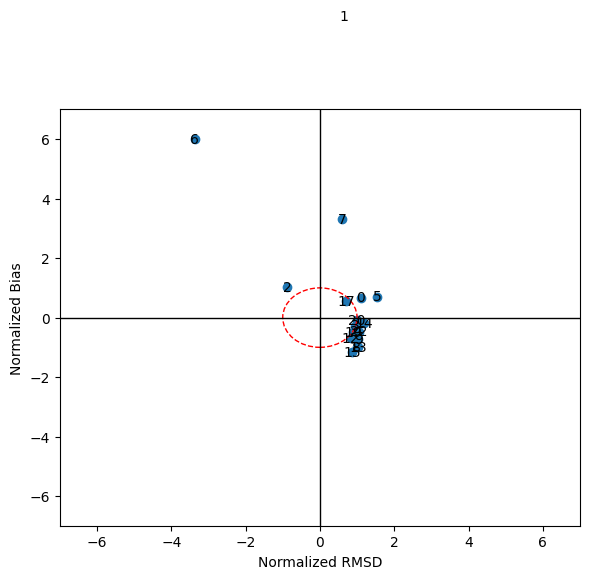

In [14]:
# Create a figure with 2 rows and 4 columns, with one larger panel for the target diagram
fig, ax = plt.subplots(1,1, figsize=(6, 6))

# Scatter plot for the target diagram
ax.scatter(stats_df['cRMSD']/stats_df['obs_std']*np.sign(1-stats_df['model_std']/stats_df['obs_std'] ), stats_df['bias']/stats_df['obs_std'])

# Add region-specific text labels
for reg in range(nreg):
    dloc = stats_df[stats_df.region==reg]
    ax.text(dloc['cRMSD'].item()/dloc['obs_std'].item()*np.sign(1-dloc['model_std'].item()/dloc['obs_std'].item()),
        dloc['bias'].item()/dloc['obs_std'].item(),
        '%s'%dloc['region'].item(), ha = 'center', va='center' )

# Centering the axes and adding lines and circle
ax.set_xlim([-7, 7])  # Adjust the limits to fit your data
ax.set_ylim([-7, 7])

# Adding vertical and horizontal lines at x=0, y=0
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Adding a circle with radius 1 centered at (0, 0)
circle = Circle((0, 0), 1, color='r', fill=False, linestyle='--')
ax.add_patch(circle)

# Set labels for the target diagram
ax.set_xlabel('Normalized RMSD')
ax.set_ylabel('Normalized Bias')

# Adjust layout to make room for colorbars and to avoid overlap
fig.tight_layout()

# Save the figure
fig.savefig('Validation_Metrics_Maps_xarray_reorganized.png')

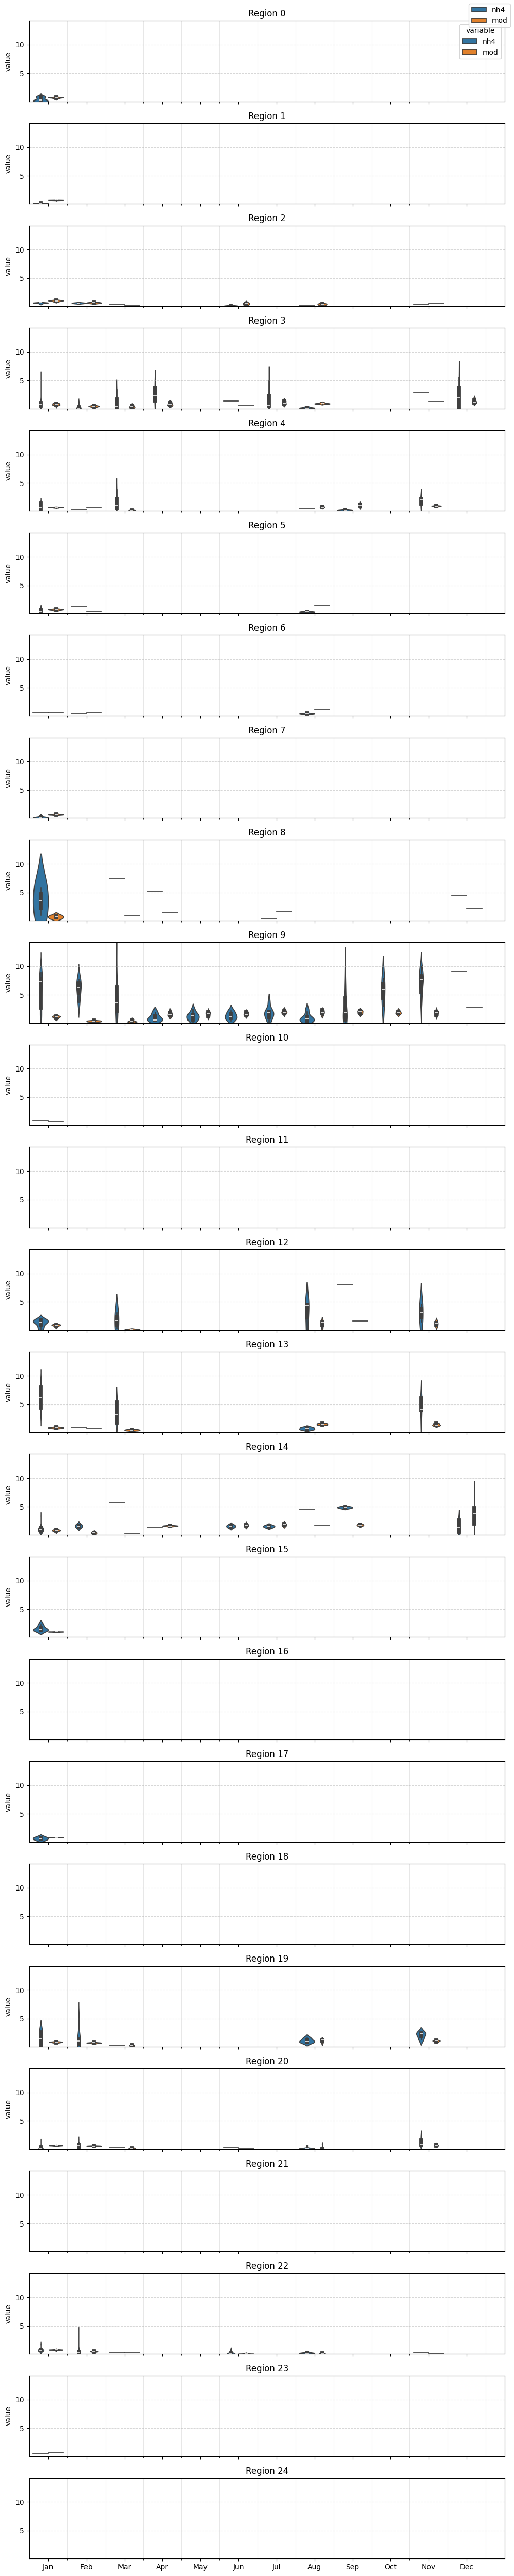

In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

maxdepth = 20
months = list(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

ncol = 1

fig, axs = plt.subplots(int(np.ceil(nreg/ncol)), ncol, figsize=(10, 2*nreg), sharex=True)
axs = axs.flatten()

for reg in range(nreg):
    ax = axs[reg]

    dloc = dflt[(dflt['reg'] == reg) & (dflt['depth'] <= maxdepth)].copy()

    # Extract month
    dloc['month'] = pd.Categorical(
        dloc['datetime'].dt.strftime('%b'),
        categories=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],ordered=True)

    if not dloc.empty:
        # 👉 reshape to long format
        dlong = dloc.melt(
            id_vars='month',
            value_vars=[var, 'mod'],
            var_name='variable',
            value_name='value'
        )

        # 👉 seaborn boxplot
        sns.violinplot(
            data=dlong,
            x='month',
            y='value',
            hue='variable',
            ax=ax,
            palette={var: 'tab:blue', 'mod': 'tab:orange'},
            dodge = True
        )

    else:
        # 👉 still create empty axis with full months
        ax.set_xticks(months)

    # 👉 formatting (applies to both empty & non-empty)
    ax.set_title(f'Region {reg}')
    ax.set_xticks(range(len(month_labels)))
    ax.set_xticklabels(month_labels)

    # minor ticks BETWEEN months
    ax.set_xticks(np.arange(0.5, 12.5, 1), minor=True)

    # grid on minor ticks (vertical separators)
    ax.grid(which='minor', axis='x', linestyle='-', alpha=0.3)

    # optional: keep horizontal grid
    ax.grid(which='major', axis='y', linestyle='--', alpha=0.5)

    # 👉 avoid repeating legends everywhere
    if reg != 0:
        ax.get_legend().remove() if ax.get_legend() else None

ymin = np.min(dflt[var])
ymax = np.max(dflt[var])
for ax in axs:
    ax.set_ylim(ymin, ymax)

# 👉 single legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()